# 06 - XGBoost Classifier

## Diabetic Foot Ulcer Risk Classification - XGBoost Model

This notebook trains an XGBoost classifier for early diabetic foot ulcer detection using multi-sensor wearable data, following the same approach as the Random Forest model.

### Objectives:
- Preprocess data with feature engineering (identical to Random Forest)
- Train XGBoost classifier
- Evaluate model performance
- Export model for mobile deployment
- Compare with Random Forest performance

In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import joblib
import os
import xgboost as xgb

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score,
    precision_score, recall_score, f1_score, roc_auc_score, roc_curve
)

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')

# Create directories if they don't exist
os.makedirs('models/XG_Boost', exist_ok=True)
os.makedirs('plots', exist_ok=True)

print("✅ Libraries imported successfully!")
print(f"XGBoost version: {xgb.__version__}")

✅ Libraries imported successfully!
XGBoost version: 2.1.1


## 1. Load Dataset

In [2]:
# Load the dataset (same dataset as Random Forest)
DATA_PATH = '../Synthetic_Data/synthetic_foot_ulcer_dataset_RISK.csv'
df = pd.read_csv(DATA_PATH)

print(f"✅ Dataset loaded: {df.shape[0]} samples × {df.shape[1]} columns")
print(f"\nDataset shape: {df.shape}")
print(f"\nFirst few rows:")
df.head()

✅ Dataset loaded: 10000 samples × 20 columns

Dataset shape: (10000, 20)

First few rows:


,temp_heel,press_heel,temp_ball,press_ball,temp_arch,press_arch,temp_toe,press_toe,spo2,heartRate,acc_x,acc_y,acc_z,gyro_x,gyro_y,gyro_z,stepCount,batteryLevel,risk_score,label
0,33.498160,58.028572,34.927976,43.946339,32.624075,26.239781,32.232334,54.647046,95.621089,81,0.239495,-0.478550,9.866665,-34.223433,-42.545393,-9.398040,59,99,0.378454,0
1,32.931085,23.624257,34.473544,35.298480,35.932924,38.670516,35.439762,47.212302,85.198974,119,-6.080159,3.358271,12.137578,-88.087821,90.418256,29.849513,34,97,0.693139,1
2,33.564242,27.289444,35.021446,37.006235,32.831767,42.708013,32.125253,53.691391,90.927254,73,-2.721560,3.565877,12.156596,212.480807,21.078883,131.341689,23,45,0.555218,0
3,35.861021,44.281370,33.103997,31.850940,40.354115,105.342867,33.693606,35.795261,95.935108,92,2.095321,0.520806,11.786854,19.289773,-13.456407,93.181492,32,67,0.662824,1
4,33.483273,46.753650,34.663689,43.651912,33.098887,42.449737,33.531707,58.868484,95.825943,73,10.116889,-2.761172,8.604085,-4.869127,-113.500037,83.399329,95,23,0.388919,0


## 2. Feature Definition

### Features to INCLUDE:
- Temperature sensors (4): temp_heel, temp_ball, temp_arch, temp_toe
- Pressure sensors (4): press_heel, press_ball, press_arch, press_toe
- Vital signs (2): spo2, heartRate
- Activity (1): stepCount

### Features to EXCLUDE:
- `batteryLevel`: System-level feature
- `risk_score`: Model output, NOT input
- Motion sensors (6): acc_x, acc_y, acc_z, gyro_x, gyro_y, gyro_z (NOT available in BLE transmission)
- Engineered motion features: acc_magnitude, gyro_magnitude (derived from unavailable sensors)

In [3]:
# Define feature groups (identical to Random Forest model)
TEMP_FEATURES = ['temp_heel', 'temp_ball', 'temp_arch', 'temp_toe']
PRESSURE_FEATURES = ['press_heel', 'press_ball', 'press_arch', 'press_toe']
VITAL_FEATURES = ['spo2', 'heartRate']
ACTIVITY_FEATURES = ['stepCount']

# All raw sensor features (WITHOUT motion sensors - not available in BLE)
RAW_SENSOR_FEATURES = (TEMP_FEATURES + PRESSURE_FEATURES + VITAL_FEATURES + 
                       ACTIVITY_FEATURES)

# Target column
TARGET = 'label'

print(f"Raw sensor features ({len(RAW_SENSOR_FEATURES)}): {RAW_SENSOR_FEATURES}")

Raw sensor features (11): ['temp_heel', 'temp_ball', 'temp_arch', 'temp_toe', 'press_heel', 'press_ball', 'press_arch', 'press_toe', 'spo2', 'heartRate', 'stepCount']


## 3. Feature Engineering

In [4]:
# Create a copy for feature engineering
df_processed = df.copy()

# =============================================================================
# ENGINEERED FEATURES (identical to Random Forest)
# =============================================================================

# Pressure features
df_processed['max_pressure'] = df_processed[PRESSURE_FEATURES].max(axis=1)
df_processed['pressure_variance'] = df_processed[PRESSURE_FEATURES].var(axis=1)

# Temperature features
df_processed['max_temp'] = df_processed[TEMP_FEATURES].max(axis=1)
df_processed['temp_variance'] = df_processed[TEMP_FEATURES].var(axis=1)

# Define engineered features
ENGINEERED_FEATURES = [
    'max_pressure', 'pressure_variance',
    'max_temp', 'temp_variance'
]

print(f"✅ Engineered features created: {ENGINEERED_FEATURES}")
print("\nEngineered features statistics:")
df_processed[ENGINEERED_FEATURES].describe()

✅ Engineered features created: ['max_pressure', 'pressure_variance', 'max_temp', 'temp_variance']

Engineered features statistics:


,max_pressure,pressure_variance,max_temp,temp_variance
count,10000.000000,10000.000000,10000.000000,10000.000000
mean,64.596223,359.000757,36.376418,3.301407
std,21.680199,431.893589,1.989464,3.612137
min,24.814384,0.256188,32.280170,0.002370
25%,50.888792,92.210175,35.082359,0.899668
50%,56.688439,175.441829,35.664349,1.729986
75%,76.954200,417.771393,37.997981,4.628611
max,119.986875,2236.700968,40.996875,17.289692


In [5]:
# Combine all features for model
ALL_FEATURES = RAW_SENSOR_FEATURES + ENGINEERED_FEATURES

print(f"\n{'='*80}")
print("FINAL FEATURE SET FOR XGBOOST MODEL TRAINING")
print(f"{'='*80}")
print(f"\nTotal features: {len(ALL_FEATURES)}")
print(f"\nRaw sensor features ({len(RAW_SENSOR_FEATURES)}):")
for i, f in enumerate(RAW_SENSOR_FEATURES, 1):
    print(f"  {i:2d}. {f}")
    
print(f"\nEngineered features ({len(ENGINEERED_FEATURES)}):")
for i, f in enumerate(ENGINEERED_FEATURES, 1):
    print(f"  {i:2d}. {f}")


FINAL FEATURE SET FOR XGBOOST MODEL TRAINING

Total features: 15

Raw sensor features (11):
   1. temp_heel
   2. temp_ball
   3. temp_arch
   4. temp_toe
   5. press_heel
   6. press_ball
   7. press_arch
   8. press_toe
   9. spo2
  10. heartRate
  11. stepCount

Engineered features (4):
   1. max_pressure
   2. pressure_variance
   3. max_temp
   4. temp_variance


## 4. Prepare Features and Target

In [6]:
# Separate features (X) and target (y)
X = df_processed[ALL_FEATURES].copy()
y = df_processed[TARGET].copy()

print(f"Feature matrix X shape: {X.shape}")
print(f"Target vector y shape: {y.shape}")
print(f"\nClass distribution:")
print(y.value_counts())

Feature matrix X shape: (10000, 15)
Target vector y shape: (10000,)

Class distribution:
label
0    6692
1    3308
Name: count, dtype: int64


In [7]:
# Train-test split (80-20) with stratification
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")
print(f"\nTraining class distribution:")
print(y_train.value_counts())
print(f"\nTest class distribution:")
print(y_test.value_counts())

Training set: 8000 samples
Test set: 2000 samples

Training class distribution:
label
0    5354
1    2646
Name: count, dtype: int64

Test class distribution:
label
0    1338
1     662
Name: count, dtype: int64


## 5. Feature Scaling

In [8]:
# Initialize and fit scaler
scaler = StandardScaler()

# Fit on training data only, transform both
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert back to DataFrame for inspection
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=ALL_FEATURES)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=ALL_FEATURES)

print("✅ Features scaled using StandardScaler")
print("\nScaled training data statistics:")
print(X_train_scaled_df.describe().loc[['mean', 'std']].round(4))

✅ Features scaled using StandardScaler

Scaled training data statistics:
      temp_heel  temp_ball  temp_arch  temp_toe  press_heel  press_ball  \
mean     0.0000     0.0000    -0.0000    0.0000     -0.0000      0.0000   
std      1.0001     1.0001     1.0001    1.0001      1.0001      1.0001   

      press_arch  press_toe    spo2  heartRate  stepCount  max_pressure  \
mean     -0.0000     0.0000  0.0000     0.0000    -0.0000        0.0000   
std       1.0001     1.0001  1.0001     1.0001     1.0001        1.0001   

      pressure_variance  max_temp  temp_variance  
mean             0.0000    0.0000         0.0000  
std              1.0001    1.0001         1.0001  


## 6. Train XGBoost Classifier

In [9]:
# Initialize XGBoost with optimized hyperparameters for medical data
xgb_model = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=1,  # Adjust if classes are imbalanced
    random_state=42,
    n_jobs=-1,
    eval_metric='logloss'
)

# Train the model
print("Training XGBoost classifier...")
xgb_model.fit(
    X_train_scaled, 
    y_train,
    verbose=False
)
print("✅ XGBoost model training complete!")

Training XGBoost classifier...
✅ XGBoost model training complete!


In [10]:
# Cross-validation score
cv_scores = cross_val_score(xgb_model, X_train_scaled, y_train, cv=5, scoring='roc_auc')

print(f"\n{'='*80}")
print("CROSS-VALIDATION RESULTS (5-Fold)")
print(f"{'='*80}")
print(f"ROC-AUC scores: {cv_scores}")
print(f"Mean ROC-AUC: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")


CROSS-VALIDATION RESULTS (5-Fold)
ROC-AUC scores: [0.98115465 0.98538899 0.98393283 0.98203188 0.98140716]
Mean ROC-AUC: 0.9828 (+/- 0.0033)


## 7. Model Evaluation

In [11]:
# Make predictions
y_pred = xgb_model.predict(X_test_scaled)
y_pred_proba = xgb_model.predict_proba(X_test_scaled)[:, 1]

# Calculate metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)

print(f"\n{'='*80}")
print("XGBOOST MODEL EVALUATION METRICS")
print(f"{'='*80}")
print(f"\n  Accuracy:  {accuracy:.4f}")
print(f"  Precision: {precision:.4f}")
print(f"  Recall:    {recall:.4f}")
print(f"  F1-Score:  {f1:.4f}")
print(f"  ROC-AUC:   {roc_auc:.4f}")


XGBOOST MODEL EVALUATION METRICS

  Accuracy:  0.9320
  Precision: 0.9109
  Recall:    0.8807
  F1-Score:  0.8955
  ROC-AUC:   0.9845


In [12]:
# Classification report
print(f"\n{'='*80}")
print("CLASSIFICATION REPORT")
print(f"{'='*80}")
print(classification_report(y_test, y_pred, target_names=['Normal (0)', 'High Risk (1)']))


CLASSIFICATION REPORT
               precision    recall  f1-score   support

   Normal (0)       0.94      0.96      0.95      1338
High Risk (1)       0.91      0.88      0.90       662

     accuracy                           0.93      2000
    macro avg       0.93      0.92      0.92      2000
 weighted avg       0.93      0.93      0.93      2000



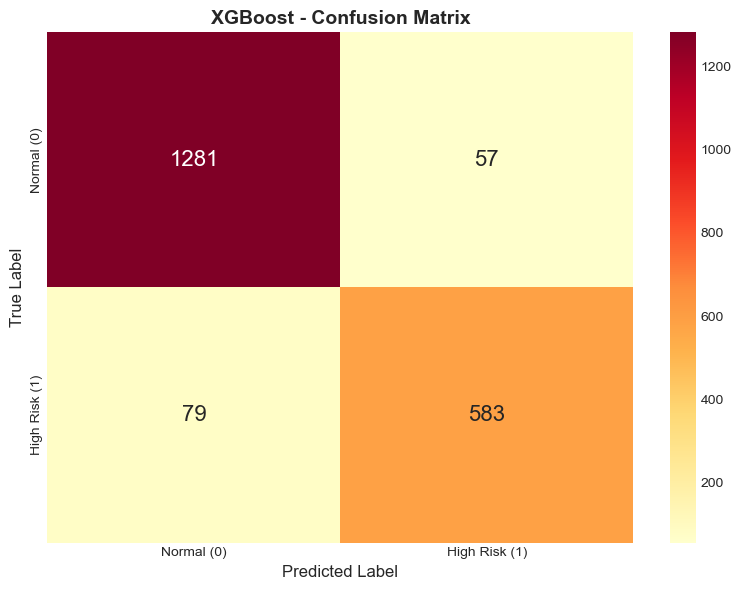

📊 Plot saved: plots/xgb_confusion_matrix.png


In [13]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='YlOrRd', 
            xticklabels=['Normal (0)', 'High Risk (1)'],
            yticklabels=['Normal (0)', 'High Risk (1)'],
            annot_kws={'size': 16}, ax=ax)

ax.set_xlabel('Predicted Label', fontsize=12)
ax.set_ylabel('True Label', fontsize=12)
ax.set_title('XGBoost - Confusion Matrix', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('plots/xgb_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print("📊 Plot saved: plots/xgb_confusion_matrix.png")

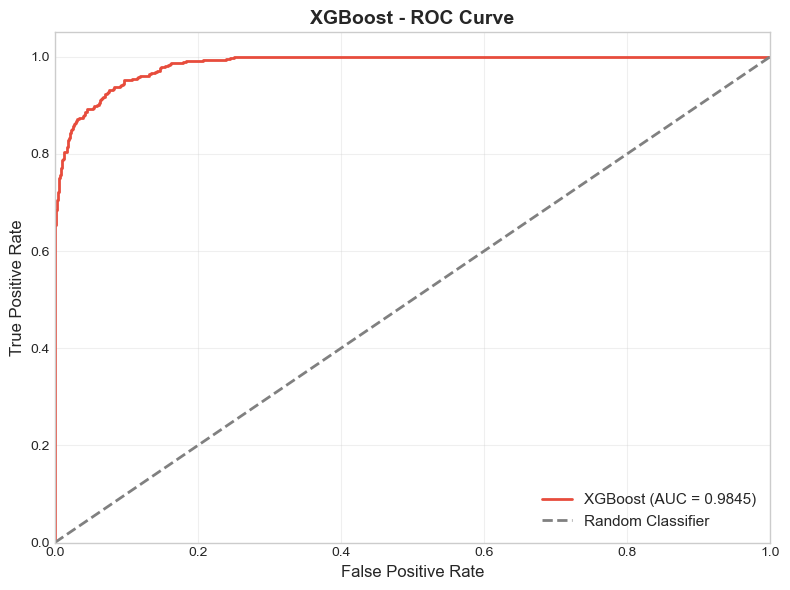

📊 Plot saved: plots/xgb_roc_curve.png


In [14]:
# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(fpr, tpr, color='#e74c3c', lw=2, label=f'XGBoost (AUC = {roc_auc:.4f})')
ax.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--', label='Random Classifier')

ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('XGBoost - ROC Curve', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('plots/xgb_roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()

print("📊 Plot saved: plots/xgb_roc_curve.png")

## 8. Feature Importance

In [15]:
# Get feature importances
feature_importance = pd.DataFrame({
    'feature': ALL_FEATURES,
    'importance': xgb_model.feature_importances_
}).sort_values('importance', ascending=False)

print(f"\n{'='*80}")
print("XGBOOST FEATURE IMPORTANCE RANKING")
print(f"{'='*80}")
print(feature_importance.to_string(index=False))


XGBOOST FEATURE IMPORTANCE RANKING
          feature  importance
         max_temp    0.311197
             spo2    0.179917
     max_pressure    0.169006
        stepCount    0.091460
pressure_variance    0.028880
        press_toe    0.026265
        temp_arch    0.025101
       press_heel    0.024194
        temp_heel    0.023246
        temp_ball    0.022417
    temp_variance    0.021725
       press_ball    0.021035
       press_arch    0.020762
         temp_toe    0.019704
        heartRate    0.015092


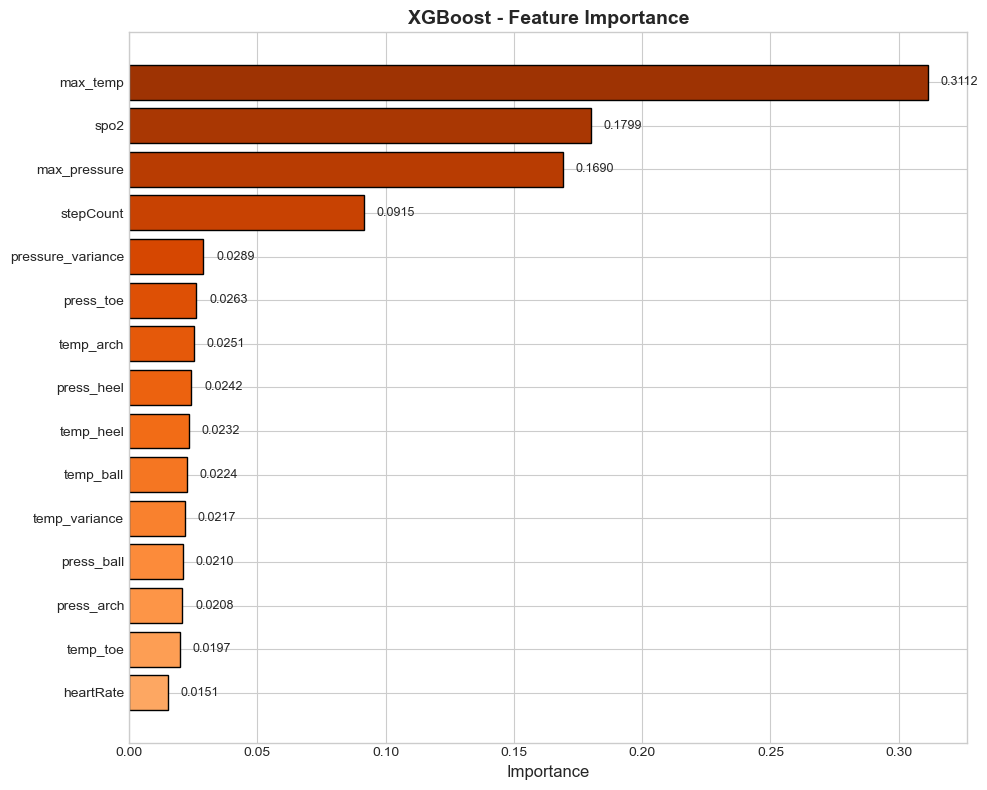

📊 Plot saved: plots/xgb_feature_importance.png


In [16]:
# Plot feature importance
fig, ax = plt.subplots(figsize=(10, 8))

colors = plt.cm.Oranges(np.linspace(0.4, 0.9, len(feature_importance)))
bars = ax.barh(feature_importance['feature'], feature_importance['importance'], 
               color=colors[::-1], edgecolor='black')

ax.set_xlabel('Importance', fontsize=12)
ax.set_title('XGBoost - Feature Importance', fontsize=14, fontweight='bold')
ax.invert_yaxis()

# Add value labels
for bar, val in zip(bars, feature_importance['importance']):
    ax.text(val + 0.005, bar.get_y() + bar.get_height()/2, 
            f'{val:.4f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('plots/xgb_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print("📊 Plot saved: plots/xgb_feature_importance.png")

## 9. Save Model and Artifacts

In [17]:
# Save the trained XGBoost model in JSON format
MODEL_PATH = 'models/XG_Boost/xgboost_model.json'
xgb_model.get_booster().save_model(MODEL_PATH)
print(f"✅ XGBoost model saved (JSON): {MODEL_PATH}")

# Also save in pickle format for Python compatibility
MODEL_PKL_PATH = 'models/XG_Boost/xgboost_model.pkl'
joblib.dump(xgb_model, MODEL_PKL_PATH)
print(f"✅ XGBoost model saved (PKL): {MODEL_PKL_PATH}")

# Save the scaler
SCALER_PATH = 'models/XG_Boost/scaler.pkl'
joblib.dump(scaler, SCALER_PATH)
print(f"✅ Scaler saved: {SCALER_PATH}")

# Save feature list
FEATURES_PATH = 'models/XG_Boost/feature_names.pkl'
joblib.dump(ALL_FEATURES, FEATURES_PATH)
print(f"✅ Feature names saved: {FEATURES_PATH}")

✅ XGBoost model saved (JSON): models/XG_Boost/xgboost_model.json
✅ XGBoost model saved (PKL): models/XG_Boost/xgboost_model.pkl
✅ Scaler saved: models/XG_Boost/scaler.pkl
✅ Feature names saved: models/XG_Boost/feature_names.pkl


In [18]:
# Save model metadata for reference
import json

metadata = {
    'model_name': 'XGBoost Classifier',
    'dataset': 'synthetic_foot_ulcer_dataset_RISK.csv',
    'features': ALL_FEATURES,
    'n_features': len(ALL_FEATURES),
    'model_params': {
        'n_estimators': 100,
        'max_depth': 5,
        'learning_rate': 0.1,
        'subsample': 0.8,
        'colsample_bytree': 0.8
    },
    'metrics': {
        'accuracy': float(accuracy),
        'precision': float(precision),
        'recall': float(recall),
        'f1_score': float(f1),
        'roc_auc': float(roc_auc)
    },
    'cv_mean_roc_auc': float(cv_scores.mean()),
    'cv_std_roc_auc': float(cv_scores.std())
}

METADATA_PATH = 'models/XG_Boost/xgb_metadata.json'
with open(METADATA_PATH, 'w') as f:
    json.dump(metadata, f, indent=4)
print(f"✅ Model metadata saved: {METADATA_PATH}")

✅ Model metadata saved: models/XG_Boost/xgb_metadata.json


## 10. Inference Example (Risk Score Generation)

In [19]:
# Demonstrate how to generate risk score from model output
print(f"\n{'='*80}")
print("RISK SCORE GENERATION EXAMPLE - XGBOOST")
print(f"{'='*80}")

# Get predictions from XGBoost
sample_indices = [0, 5, 10, 15, 20]
sample_data = X_test_scaled[sample_indices]

# Risk score = probability of class 1 (High Risk)
risk_scores = xgb_model.predict_proba(sample_data)[:, 1]
predicted_classes = xgb_model.predict(sample_data)
actual_classes = y_test.iloc[sample_indices].values

print("\nSample predictions:")
print("-" * 60)
print(f"{'Index':<10} {'Risk Score':<15} {'Predicted':<15} {'Actual':<10}")
print("-" * 60)

for i, (idx, rs, pred, actual) in enumerate(zip(sample_indices, risk_scores, predicted_classes, actual_classes)):
    pred_label = 'High Risk' if pred == 1 else 'Normal'
    actual_label = 'High Risk' if actual == 1 else 'Normal'
    print(f"{idx:<10} {rs:<15.4f} {pred_label:<15} {actual_label:<10}")

print("\n📝 Note: Risk score is the model's probabilistic output (0.0 - 1.0)")
print("   - < 0.3: Low risk")
print("   - 0.3 - 0.6: Moderate risk")
print("   - > 0.6: High risk")


RISK SCORE GENERATION EXAMPLE - XGBOOST

Sample predictions:
------------------------------------------------------------
Index      Risk Score      Predicted       Actual    
------------------------------------------------------------
0          0.0013          Normal          Normal    
5          0.0064          Normal          Normal    
10         0.0025          Normal          Normal    
15         0.9979          High Risk       High Risk 
20         0.0811          Normal          Normal    

📝 Note: Risk score is the model's probabilistic output (0.0 - 1.0)
   - < 0.3: Low risk
   - 0.3 - 0.6: Moderate risk
   - > 0.6: High risk


## 11. Summary

In [20]:
print(f"\n{'='*80}")
print("XGBOOST MODEL - TRAINING COMPLETE")
print(f"{'='*80}")

print(f"\n📊 Model Performance:")
print(f"   - Accuracy:  {accuracy:.4f}")
print(f"   - Precision: {precision:.4f}")
print(f"   - Recall:    {recall:.4f}")
print(f"   - F1-Score:  {f1:.4f}")
print(f"   - ROC-AUC:   {roc_auc:.4f}")

print(f"\n📁 Saved Files (models/XG_Boost/):")
print(f"   - xgboost_model.json (XGBoost model)")
print(f"   - xgboost_model.pkl (XGBoost model - Python compatible)")
print(f"   - scaler.pkl (StandardScaler)")
print(f"   - feature_names.pkl (Feature list)")
print(f"   - xgb_metadata.json (Model metadata)")

print(f"\n📈 Plots (plots/):")
print(f"   - xgb_confusion_matrix.png")
print(f"   - xgb_roc_curve.png")
print(f"   - xgb_feature_importance.png")

print(f"\n✅ XGBoost pipeline complete!")
print(f"\n💡 Model ready for deployment to Flutter mobile app!")


XGBOOST MODEL - TRAINING COMPLETE

📊 Model Performance:
   - Accuracy:  0.9320
   - Precision: 0.9109
   - Recall:    0.8807
   - F1-Score:  0.8955
   - ROC-AUC:   0.9845

📁 Saved Files (models/XG_Boost/):
   - xgboost_model.json (XGBoost model)
   - xgboost_model.pkl (XGBoost model - Python compatible)
   - scaler.pkl (StandardScaler)
   - feature_names.pkl (Feature list)
   - xgb_metadata.json (Model metadata)

📈 Plots (plots/):
   - xgb_confusion_matrix.png
   - xgb_roc_curve.png
   - xgb_feature_importance.png

✅ XGBoost pipeline complete!

💡 Model ready for deployment to Flutter mobile app!
